2025-06-08 13:40:42.675307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749379242.690088   18656 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749379242.694393   18656 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-08 13:40:42.711905: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


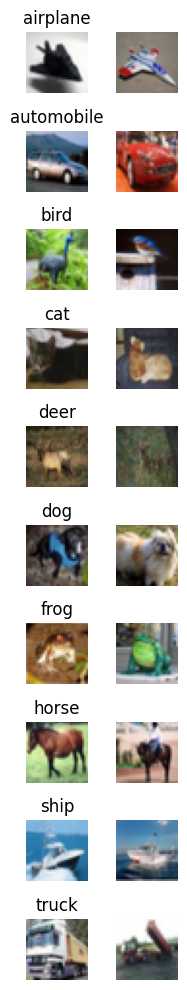

In [1]:

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Завантаження та підготовка даних CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Виведення по 2 зразки з кожного класу
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Побудова словника для прикладів
examples = {i: [] for i in range(10)}

for img, label in zip(X_train, y_train):
    lbl = label[0]
    if len(examples[lbl]) < 2:
        examples[lbl].append(img)
    if all(len(v) == 2 for v in examples.values()):
        break

# Вивід сітки з 2 зразками на клас
fig, axes = plt.subplots(10, 2, figsize=(2, 10))
for class_id in range(10):
    for j in range(2):
        ax = axes[class_id, j]
        ax.imshow(examples[class_id][j])
        ax.axis('off')
        if j == 0:
            ax.set_title(class_names[class_id])
plt.tight_layout()
plt.show()

# Нормалізація даних
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Перетворення міток у формат one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available devices:")
print(tf.config.list_physical_devices())

TensorFlow version: 2.18.0
Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

input_shape = (32, 32, 3)

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_cnn.summary()


/home/dmitry/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1749379248.409140   18656 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13687 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
batch_size = 32
epochs=10

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn = model_cnn.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), batch_size=batch_size)

Epoch 1/10


I0000 00:00:1749379251.814899   18746 service.cc:148] XLA service 0x703b9c006230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749379251.814938   18746 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti Laptop GPU, Compute Capability 8.6
2025-06-08 13:40:51.837479: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749379251.958203   18746 cuda_dnn.cc:529] Loaded cuDNN version 90300


  43/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1282 - loss: 2.3005

I0000 00:00:1749379253.759254   18746 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1276/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.3110 - loss: 1.8561

2025-06-08 13:41:01.234686: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 4 bytes spill stores, 4 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3286 - loss: 1.8123 - val_accuracy: 0.5518 - val_loss: 1.2488
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5493 - loss: 1.2548 - val_accuracy: 0.5950 - val_loss: 1.1379
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6270 - loss: 1.0605 - val_accuracy: 0.6780 - val_loss: 0.9300
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6710 - loss: 0.9395 - val_accuracy: 0.6794 - val_loss: 0.9070
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7011 - loss: 0.8618 - val_accuracy: 0.7007 - val_loss: 0.8675
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7241 - loss: 0.7886 - val_accuracy: 0.7153 - val_loss: 0.8163
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7454 - loss: 0.7375 - val_accuracy: 0.7215 - val_loss: 0.7971
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7629 - loss: 0.6816 - val_accura

In [5]:
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Завантаження попередньо навчених моделей без верхніх шарів
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Додавання верхніх шарів для класифікації
def create_model(base_model):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(10, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

model_vgg = create_model(base_model_vgg)
model_resnet = create_model(base_model_resnet)

model_vgg.summary()
model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 14,781,642 (56.39 MB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 23,798,154 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [6]:
batch_size = 32
epochs=10

# Компіляція моделей
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Навчання моделей
history_vgg = model_vgg.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), batch_size=batch_size)
history_resnet = model_resnet.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), batch_size=batch_size)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.2334 - loss: 1.9372 - val_accuracy: 0.4658 - val_loss: 1.3730
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s -47623us/step - accuracy: 0.4633 - loss: 1.4020 - val_accuracy: 0.5510 - val_loss: 1.2033
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5810 - loss: 1.1486 - val_accuracy: 0.6400 - val_loss: 1.0435
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6652 - loss: 0.9395 - val_accuracy: 0.6687 - val_loss: 0.9274
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7079 - loss: 0.8371 - val_accuracy: 0.6958 - val_loss: 0.8753
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7378 - loss: 0.7479 - val_accuracy: 0.7415 - val_loss: 0.7655
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7781 - loss: 0.6494 - val_accuracy: 0.7389 - val_loss: 0.7675
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.79

2025-06-08 13:48:41.042602: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_14794_0', 112 bytes spill stores, 224 bytes spill loads

2025-06-08 13:48:41.172737: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_14794', 220 bytes spill stores, 576 bytes spill loads

2025-06-08 13:48:41.214743: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_15014', 24 bytes spill stores, 24 bytes spill loads

2025-06-08 13:48:41.215676: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_15014', 60 bytes spill stores, 64 bytes spill loads

2025-06-08 13:50:34.301492: E external/local_xla/x

1385/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.4459 - loss: 1.6670

2025-06-08 13:51:24.368608: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng46{k2=7,k5=2,k14=5} for conv (f32[256,256,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,16,2,2]{3,2,1,0}, f32[256,16,2,2]{3,2,1,0}), window={size=2x2 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-06-08 13:51:24.369937: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1m50.58481695s
Trying algorithm eng46{k2=7,k5=2,k14=5} for conv (f32[256,256,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,16,2,2]{3,2,1,0}, f32[256,16,2,2]{3,2,1,0}), window={size=2x2 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_c

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 106ms/step - accuracy: 0.4516 - loss: 1.6448 - val_accuracy: 0.5153 - val_loss: 1.3893
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ -74s 23ms/step - accuracy: 0.5815 - loss: 1.2030 - val_accuracy: 0.5007 - val_loss: 1.4940
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6311 - loss: 1.0780 - val_accuracy: 0.5627 - val_loss: 1.2564
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6273 - loss: 1.0728 - val_accuracy: 0.4445 - val_loss: 1.6494
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6543 - loss: 1.0032 - val_accuracy: 0.5901 - val_loss: 1.1504
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6447 - loss: 1.0186 - val_accuracy: 0.6549 - val_loss: 0.9983
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6690 - loss: 0.9589 - val_accuracy: 0.6919 - val_loss: 0.9032
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.6781 - loss: 0

In [7]:
# import cv2
# import numpy as np

# # === 1. Завантаження класів COCO ===
# with open("coco.names", "r") as f:
#     classes = [line.strip() for line in f.readlines()]

# # Кольори для кожного класу
# colors = np.random.uniform(0, 255, size=(len(classes), 3))

# # === 2. Завантаження попередньо навчених вагів YOLO та конфігурації ===
# net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
# layer_names = net.getLayerNames()
# output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# # === 3. Функція для завантаження зображення та детекції об'єктів ===
# def detect_objects(image_path):
#     img = cv2.imread(image_path)
#     if img is None:
#         print(f"❌ Зображення не знайдено: {image_path}")
#         return
    
#     height, width = img.shape[:2]
    
#     # Підготовка зображення для YOLO
#     blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
#     net.setInput(blob)
#     outs = net.forward(output_layers)
    
#     class_ids = []
#     confidences = []
#     boxes = []
    
#     for out in outs:
#         for detection in out:
#             scores = detection[5:]
#             class_id = np.argmax(scores)
#             confidence = scores[class_id]
#             if confidence > 0.5:
#                 center_x = int(detection[0] * width)
#                 center_y = int(detection[1] * height)
#                 w = int(detection[2] * width)
#                 h = int(detection[3] * height)
                
#                 x = int(center_x - w / 2)
#                 y = int(center_y - h / 2)
                
#                 boxes.append([x, y, w, h])
#                 confidences.append(float(confidence))
#                 class_ids.append(class_id)
    
#     indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
    
#     for i in range(len(boxes)):
#         if i in indexes:
#             x, y, w, h = boxes[i]
#             label = str(classes[class_ids[i]])
#             confidence = confidences[i]
#             color = colors[class_ids[i]]
#             cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
#             cv2.putText(img, label + " " + str(round(confidence, 2)), 
#                         (x, y + 30), cv2.FONT_HERSHEY_PLAIN, 3, color, 3)
    
#     cv2.imshow("Image", img)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

# # === 4. Приклад використання ===
# detect_objects("./data/pexels-charles-kettor-268979-1077785.jpg")


In [8]:
import matplotlib.pyplot as plt

def ShowTrainingHistory(history) :

    # Show training history
    h = history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])   

Train Acc      0.7852799892425537
Validation Acc 0.7282999753952026


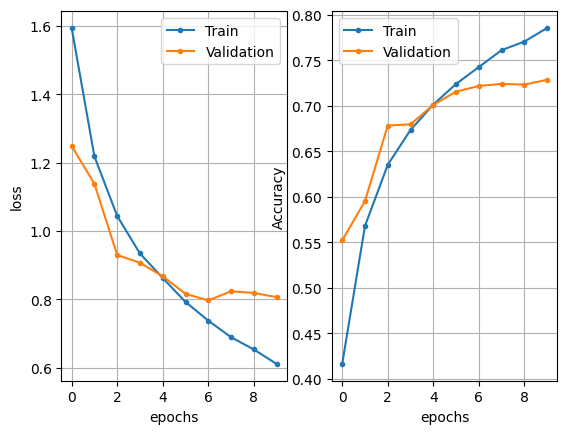

In [9]:
history = history_cnn.history
ShowTrainingHistory(history)

Train Acc      0.8290200233459473
Validation Acc 0.7494999766349792


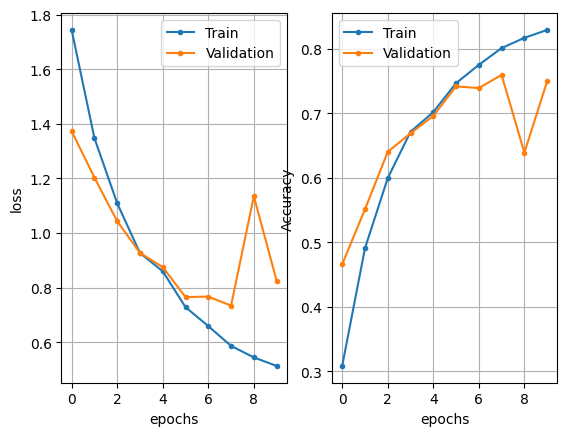

In [10]:
history = history_vgg.history
ShowTrainingHistory(history)

Train Acc      0.7468000054359436
Validation Acc 0.7405999898910522


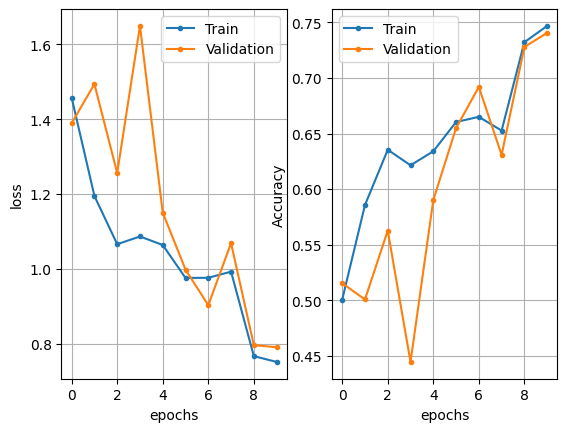

In [11]:
history = history_resnet.history
ShowTrainingHistory(history)

In [12]:
loss_cnn, acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)
loss_vgg, acc_vgg = model_vgg.evaluate(X_test, y_test, verbose=0)
loss_resnet, acc_resnet = model_resnet.evaluate(X_test, y_test, verbose=0)

print(f"CNN Accuracy: {acc_cnn:.4f}")
print(f"VGG16 Accuracy: {acc_vgg:.4f}")
print(f"ResNet Accuracy: {acc_resnet:.4f}")

CNN Accuracy: 0.7283
VGG16 Accuracy: 0.7495
ResNet Accuracy: 0.7406


In [58]:
from tensorflow.keras.layers import BatchNormalization, Activation

input_shape = (32, 32, 3)

model = Sequential()

# === First convolutional block ===
model.add(Conv2D(64, (3, 3), padding='same', use_bias=False, input_shape=input_shape))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.4))

# === Second convolutional block ===
model.add(Conv2D(128, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.6))

# === Third convolutional block ===
model.add(Conv2D(256, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(256, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(256, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dropout(0.7))

# === Fourth (was Fifth) convolutional block ===
model.add(Conv2D(512, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.8))

# === Fully connected layers ===
model.add(Flatten())

model.add(Dense(256, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.85))

# === Output layer ===
model.add(Dense(10, activation='softmax'))

# Show the model
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_112 (Conv2D)             │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_87          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_88          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_117 (Conv2D)             │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_89          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 8, 8, 256)      │             

 Total params: 5,021,386 (19.16 MB)

 Trainable params: 5,017,546 (19.14 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

batch_size = 32
epochs=50

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn_custom = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.1587 - loss: 2.8191 - val_accuracy: 0.3045 - val_loss: 1.8250
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3576 - loss: 1.7137 - val_accuracy: 0.4473 - val_loss: 1.5241
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4845 - loss: 1.4123 - val_accuracy: 0.5751 - val_loss: 1.1656
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.5608 - loss: 1.2429 - val_accuracy: 0.6250 - val_loss: 1.0493
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6134 - loss: 1.1205 - val_accuracy: 0.6414 - val_loss: 1.0049
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6465 - loss: 1.0273 - val_accuracy: 0.6757 - val_loss: 0.8882
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6763 - loss: 0.9471 - val_accuracy: 0.7184 - val_loss: 0.8030
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6986 -

Train Acc      0.8587200045585632
Validation Acc 0.847599983215332


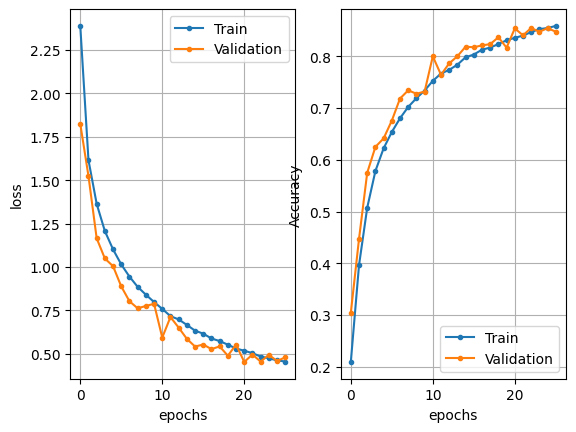

In [60]:
history = history_cnn_custom.history
ShowTrainingHistory(history)

In [61]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Model Accuracy: {acc:.4f}")

Model Accuracy: 0.8539


In [104]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

input_shape = (32, 32, 3)

# Завантаження базової моделі без "голови"
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)


In [105]:
for layer in base_model.layers[-8:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.6)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)



In [106]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetuned = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.2663 - loss: 2.0515 - val_accuracy: 0.6953 - val_loss: 0.9559
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6137 - loss: 1.1940 - val_accuracy: 0.7423 - val_loss: 0.7939
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7109 - loss: 0.9425 - val_accuracy: 0.7779 - val_loss: 0.6855
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.7605 - loss: 0.7950 - val_accuracy: 0.8068 - val_loss: 0.6313
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7982 - loss: 0.6882 - val_accuracy: 0.8114 - val_loss: 0.5775
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8280 - loss: 0.5898 - val_accuracy: 0.8221 - val_loss: 0.5739
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8483 - loss: 0.5239 - val_accuracy: 0.8269 - val_loss: 0.5644
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8683 -

Train Acc      0.9421799778938293
Validation Acc 0.8522999882698059


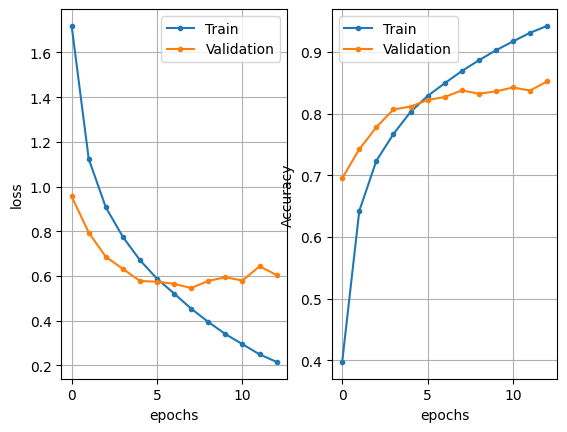

In [107]:
history = history_finetuned.history
ShowTrainingHistory(history)

In [108]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Model Accuracy: {acc:.4f}")

Model Accuracy: 0.8376
